# Chương 2 - Phần 2 - II. Bài tập thực hành Canny

Nội dung tập trung vào cách dùng hàm Canny, ảnh hưởng của tham số và cách kết
hợp Canny với phân đoạn, nhận dạng hình dạng.


## Chuẩn bị thư viện, dữ liệu và hàm hỗ trợ


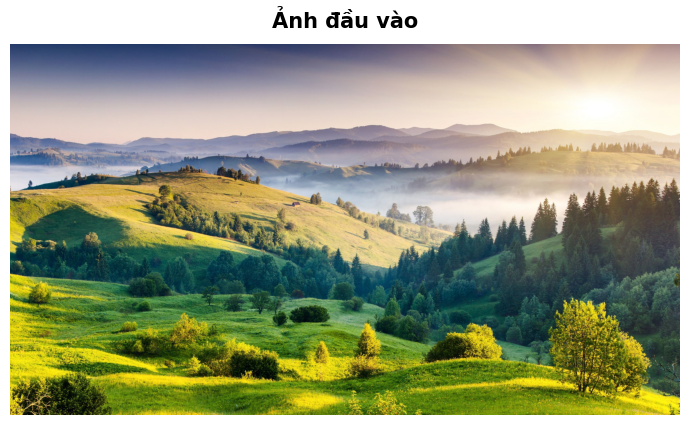

In [22]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import feature, img_as_ubyte
from skimage.color import rgb2gray

IMAGE_PATH = 'image/sample_chapter_part_2.jpg'
OUTPUT_DIR = Path('outputs_chapter_2_part_2')
OUTPUT_DIR.mkdir(exist_ok=True)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(IMAGE_PATH)

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
gray_float = rgb2gray(image_rgb)

def show_and_save(items, filename, cols=2):
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5.2 * rows), squeeze=False)
    for ax, (title, img) in zip(axes.ravel(), items):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
        ax.axis('off')
    for ax in axes.ravel()[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def edge_ratio(edge_image):
    return 100 * float(np.mean(edge_image > 0))

show_and_save([('Ảnh đầu vào', image_rgb)], 'II_0_anh_dau_vao.png', cols=1)


# Câu II.1. Thực hiện thuật toán Canny bằng các thư viện

## Ý 1: OpenCV - phân tích hàm `cv2.Canny`

```python
cv2.Canny(image, threshold1, threshold2, apertureSize=3, L2gradient=False)
```

- `image`: ảnh xám 8-bit đầu vào.
- `threshold1`: ngưỡng thấp. Pixel gradient dưới ngưỡng này bị loại.
- `threshold2`: ngưỡng cao. Pixel gradient trên ngưỡng này được xác định là cạnh mạnh.
- Pixel nằm giữa hai ngưỡng chỉ được giữ khi nối với cạnh mạnh.
- `apertureSize`: kích thước Sobel dùng để tính gradient, thường là `3`.
- `L2gradient=True`: tính độ lớn gradient chính xác hơn theo căn bậc hai tổng bình phương.

Trong ví dụ, ngưỡng `80-160` giữ các đường biên chính và loại phần lớn biến đổi
cường độ yếu.


Tỷ lệ pixel cạnh: 8.95%


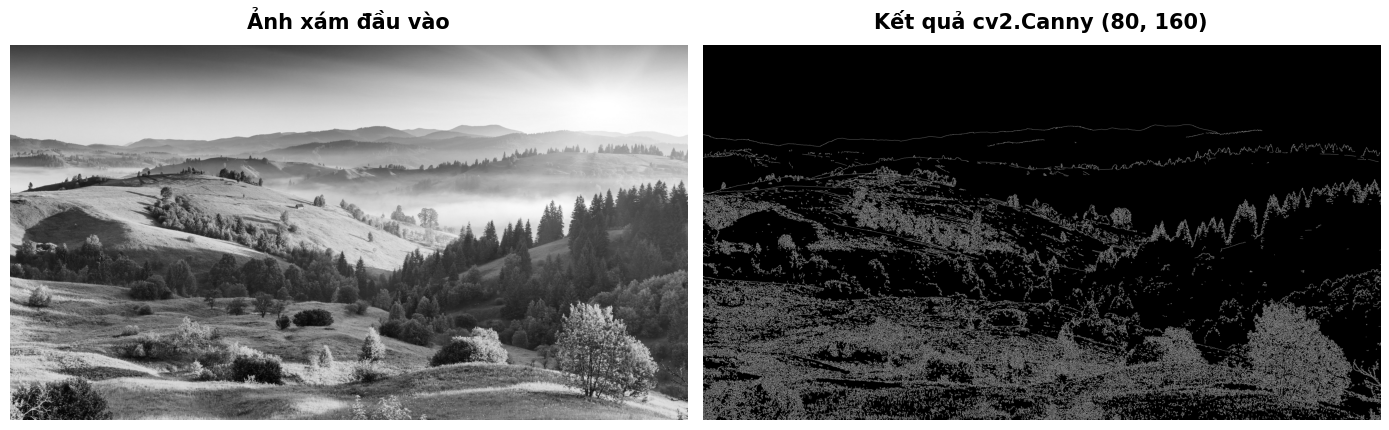

In [23]:
opencv_edges = cv2.Canny(
    gray,
    threshold1=80,
    threshold2=160,
    apertureSize=3,
    L2gradient=True,
)

print(f'Tỷ lệ pixel cạnh: {edge_ratio(opencv_edges):.2f}%')
cv2.imwrite(str(OUTPUT_DIR / 'II_1_canny_opencv.png'), opencv_edges)
show_and_save(
    [('Ảnh xám đầu vào', gray), ('Kết quả cv2.Canny (80, 160)', opencv_edges)],
    'II_1_canny_opencv.png',
    cols=2,
)


## Ý 2: Scikit-image - phân tích hàm `skimage.feature.canny`

```python
feature.canny(image, sigma=1.0, low_threshold=None, high_threshold=None)
```

- `image`: ảnh xám dạng float, thường trong khoảng `0-1`.
- `sigma`: độ lệch chuẩn của bộ lọc Gaussian bên trong hàm. Giá trị lớn làm
  mượt mạnh hơn và giảm các cạnh nhỏ.
- `low_threshold`, `high_threshold`: ngưỡng thấp và cao dùng cho liên kết cạnh.
- Kết quả trả về là ảnh Boolean: `True` tại pixel cạnh và `False` tại nền.

Với `sigma=1.4`, ngưỡng `0.10-0.25`, kết quả tập trung vào các đường biên rõ
và vẫn giữ được nhiều chi tiết của vật thể.


Tỷ lệ pixel cạnh: 7.11%


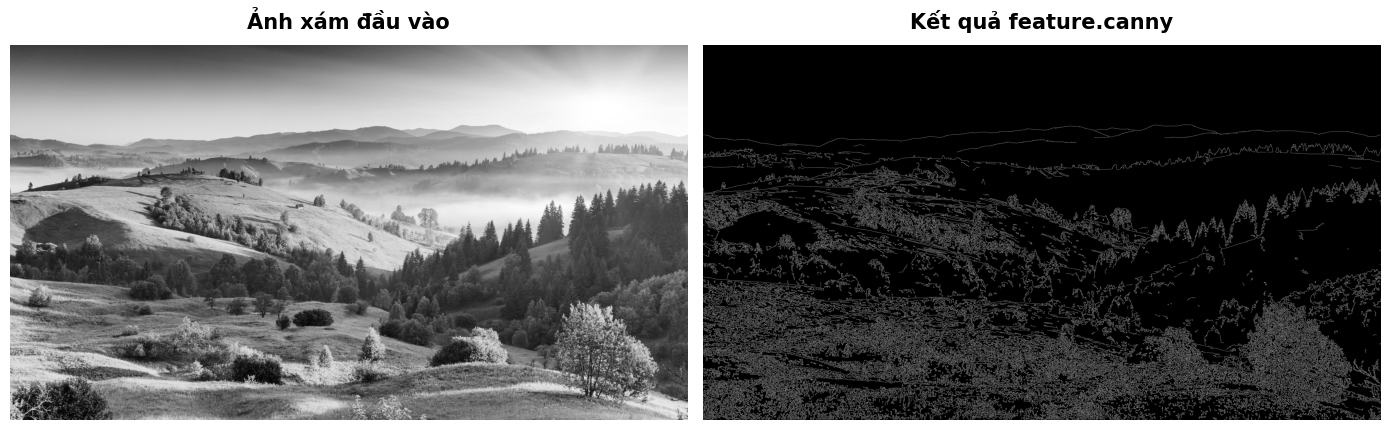

In [24]:
skimage_edges_bool = feature.canny(
    gray_float,
    sigma=1.4,
    low_threshold=0.10,
    high_threshold=0.25,
)
skimage_edges = img_as_ubyte(skimage_edges_bool)

print(f'Tỷ lệ pixel cạnh: {edge_ratio(skimage_edges):.2f}%')
cv2.imwrite(str(OUTPUT_DIR / 'II_1_canny_skimage.png'), skimage_edges)
show_and_save(
    [('Ảnh xám đầu vào', gray_float), ('Kết quả feature.canny', skimage_edges)],
    'II_1_canny_skimage.png',
    cols=2,
)


### Nhận xét Câu II.1

- `cv2.Canny` cần hai ngưỡng và cho phép chọn cách tính gradient; hàm phù hợp
  khi đầu vào là ảnh xám 8-bit.
- `feature.canny` tích hợp tham số `sigma`, nhận ảnh float và trả về ảnh Boolean.
- Hai hàm đều dùng ngưỡng kép để giữ cạnh yếu có liên kết với cạnh mạnh.


# Câu II.2. Thay đổi tham số và quan sát kết quả

## Ý 1: Thay đổi `sigma`, ngưỡng thấp và ngưỡng cao

Giá trị mốc là `sigma=1.0`, ngưỡng thấp `0.10`, ngưỡng cao `0.20`.
Mỗi tiêu đề hình ghi trực tiếp bộ tham số và tỷ lệ pixel cạnh thu được.


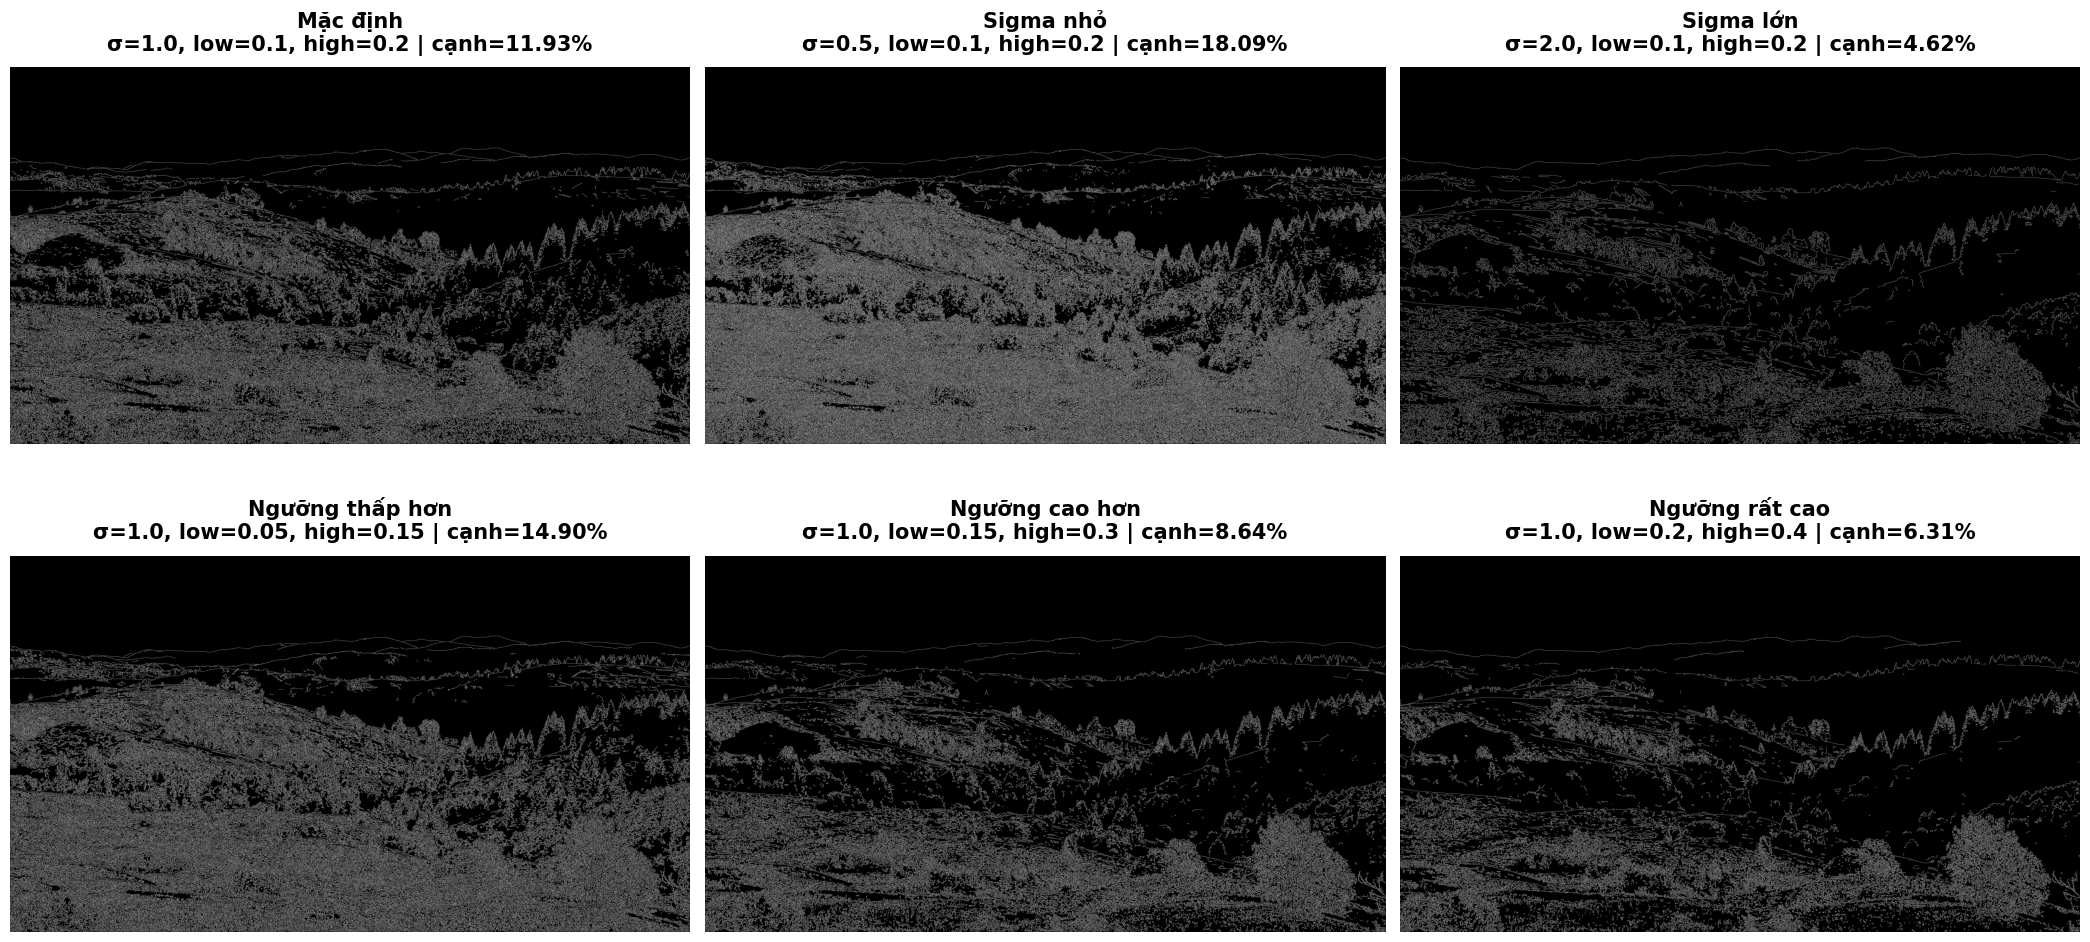

In [25]:
configs = [
    ('Mặc định', 1.0, 0.10, 0.20),
    ('Sigma nhỏ', 0.5, 0.10, 0.20),
    ('Sigma lớn', 2.0, 0.10, 0.20),
    ('Ngưỡng thấp hơn', 1.0, 0.05, 0.15),
    ('Ngưỡng cao hơn', 1.0, 0.15, 0.30),
    ('Ngưỡng rất cao', 1.0, 0.20, 0.40),
]

parameter_results = []
for name, sigma, low, high in configs:
    edges = feature.canny(
        gray_float,
        sigma=sigma,
        low_threshold=low,
        high_threshold=high,
    )
    ratio = edge_ratio(edges)
    title = f'{name}\nσ={sigma}, low={low}, high={high} | cạnh={ratio:.2f}%'
    parameter_results.append((title, edges))

show_and_save(parameter_results, 'II_2_thay_doi_tham_so.png', cols=3)


## Ý 2: So sánh với giá trị mặc định

### a) Thay đổi `sigma`

Giữ nguyên hai ngưỡng mặc định `0.10-0.20`, chỉ thay đổi `sigma`.


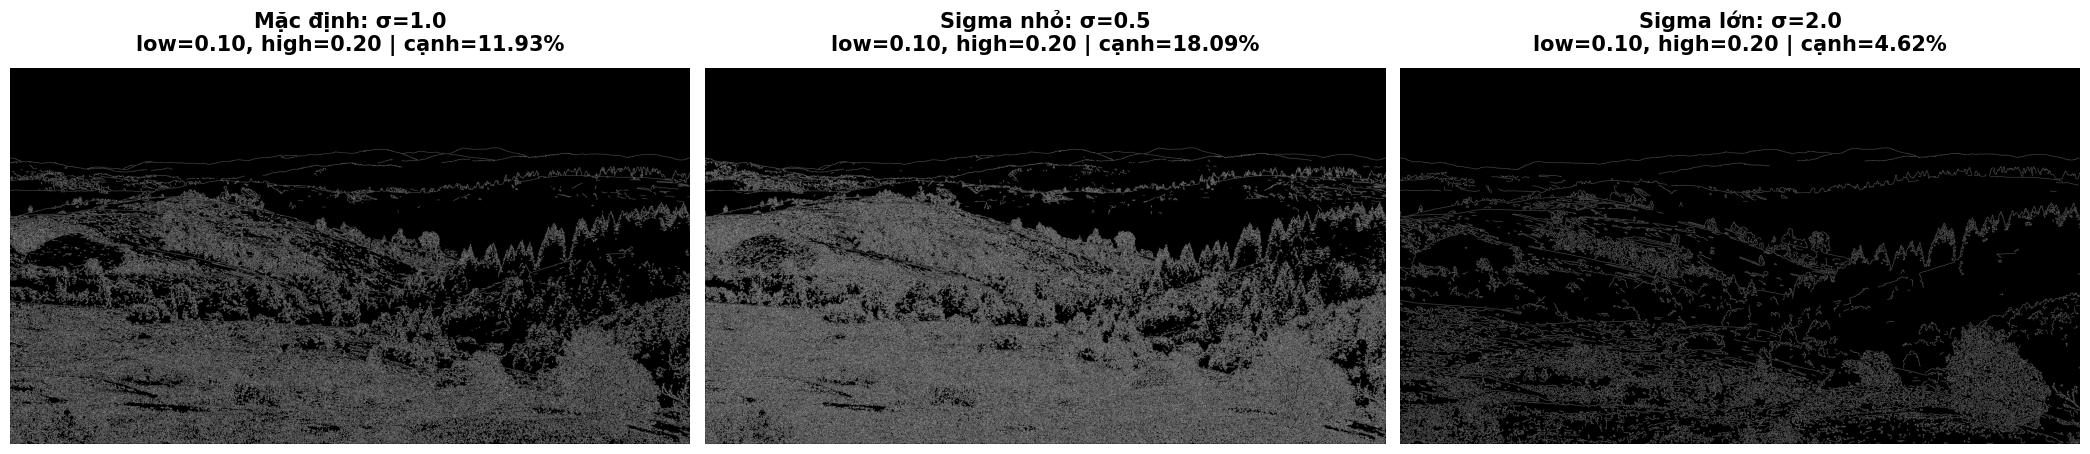

In [26]:
sigma_results = []
for name, sigma in [('Mặc định', 1.0), ('Sigma nhỏ', 0.5), ('Sigma lớn', 2.0)]:
    edges = feature.canny(gray_float, sigma=sigma, low_threshold=0.10, high_threshold=0.20)
    sigma_results.append((
        f'{name}: σ={sigma}\nlow=0.10, high=0.20 | cạnh={edge_ratio(edges):.2f}%',
        edges,
    ))

show_and_save(sigma_results, 'II_2_so_sanh_sigma_voi_mac_dinh.png', cols=3)


**Nhận xét:** So với mặc định, `sigma=0.5` giữ nhiều cạnh nhỏ và nhiễu hơn;
`sigma=2.0` làm mượt mạnh nên số cạnh giảm, một số chi tiết nhỏ bị mất.

### b) Thay đổi ngưỡng thấp và ngưỡng cao

Giữ nguyên `sigma=1.0`, chỉ thay đổi cặp ngưỡng.


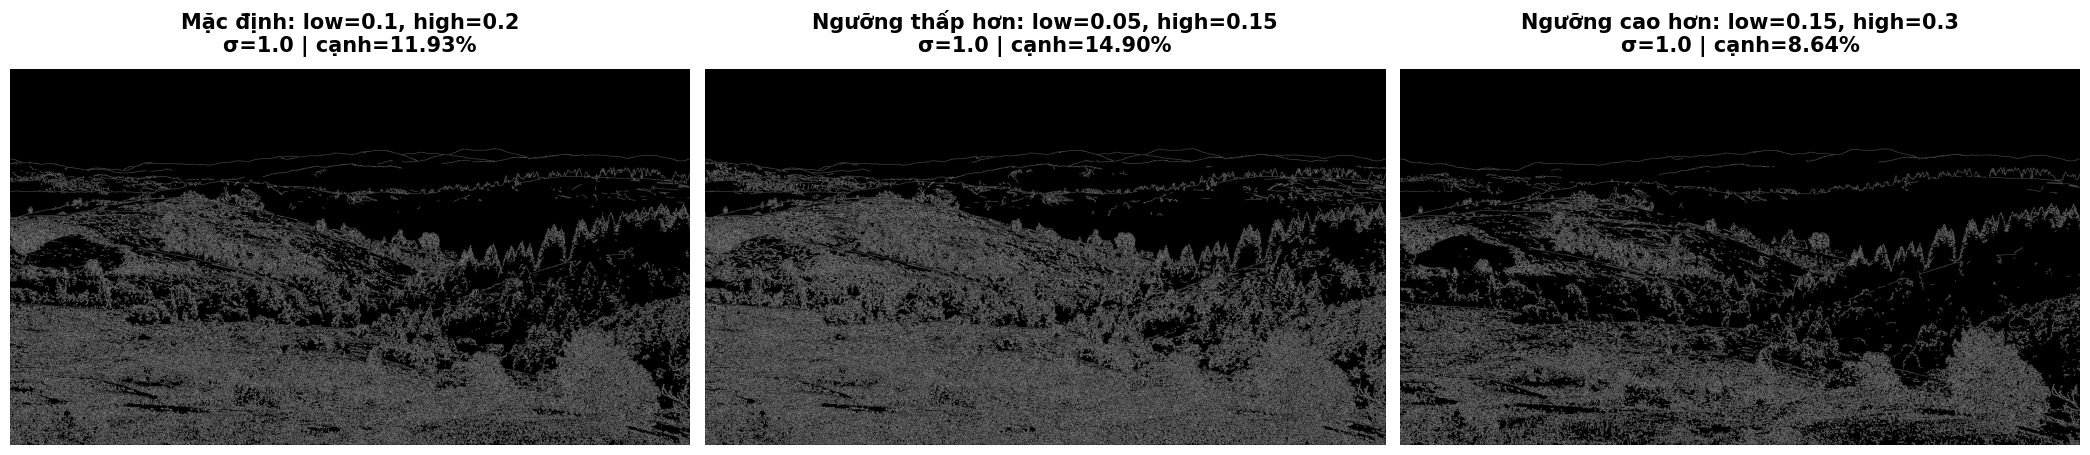

In [27]:
threshold_results = []
threshold_configs = [
    ('Mặc định', 0.10, 0.20),
    ('Ngưỡng thấp hơn', 0.05, 0.15),
    ('Ngưỡng cao hơn', 0.15, 0.30),
]
for name, low, high in threshold_configs:
    edges = feature.canny(gray_float, sigma=1.0, low_threshold=low, high_threshold=high)
    threshold_results.append((
        f'{name}: low={low}, high={high}\nσ=1.0 | cạnh={edge_ratio(edges):.2f}%',
        edges,
    ))

show_and_save(threshold_results, 'II_2_so_sanh_nguong_voi_mac_dinh.png', cols=3)


**Nhận xét:** So với mặc định, cặp ngưỡng thấp hơn giữ thêm cạnh yếu nhưng dễ
tạo cạnh không cần thiết. Cặp ngưỡng cao hơn loại nhiều cạnh yếu, làm kết quả
gọn hơn nhưng có thể khiến đường biên bị đứt.


# Câu II.3. Áp dụng Canny cho các loại ảnh khác nhau

## Phần 1

### a) Ảnh có nhiều nhiễu

Đọc ảnh input riêng `image/input_II_3_anh_nhieu.png`. Median giúp loại các
điểm nhiễu trước khi tìm cạnh.

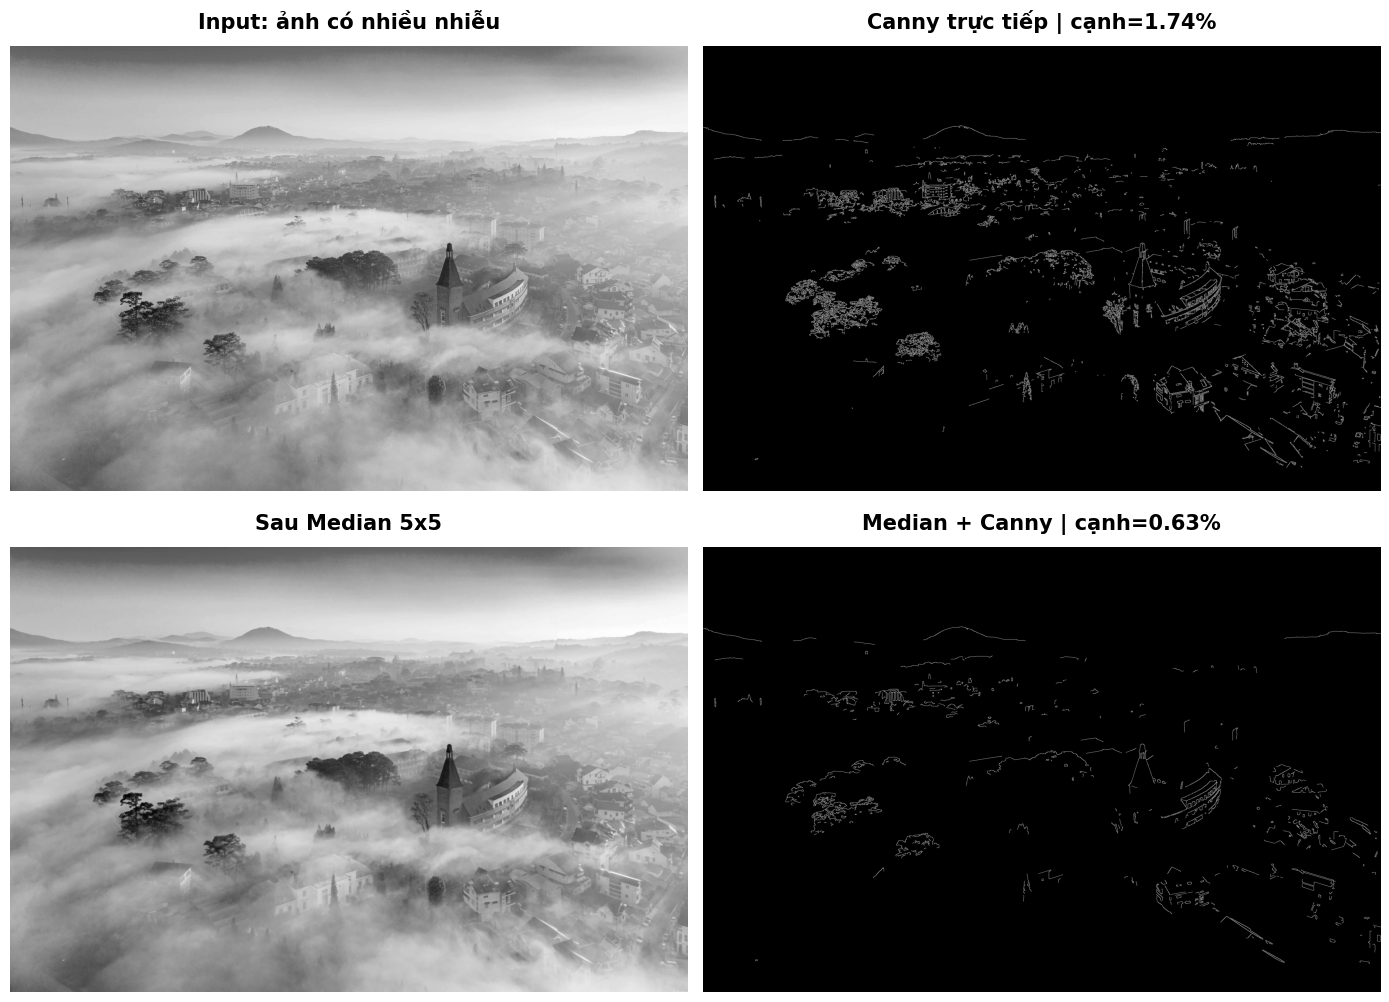

In [28]:
NOISY_INPUT = 'image/input_II_3_anh_nhieu.jpg'
salt_pepper = cv2.imread(NOISY_INPUT, cv2.IMREAD_GRAYSCALE)
if salt_pepper is None:
    raise FileNotFoundError(NOISY_INPUT)

noisy_direct = cv2.Canny(salt_pepper, 80, 160)
noisy_filtered = cv2.medianBlur(salt_pepper, 5)
noisy_edges = cv2.Canny(noisy_filtered, 80, 160)

show_and_save(
    [
        ('Input: ảnh có nhiều nhiễu', salt_pepper),
        (f'Canny trực tiếp | cạnh={edge_ratio(noisy_direct):.2f}%', noisy_direct),
        ('Sau Median 5x5', noisy_filtered),
        (f'Median + Canny | cạnh={edge_ratio(noisy_edges):.2f}%', noisy_edges),
    ],
    'II_3_anh_nhieu.png',
    cols=2,
)

### b) Ảnh có độ tương phản thấp

Đọc ảnh input riêng `image/input_II_3_tuong_phan_thap.png`. CLAHE tăng tương
phản cục bộ để làm rõ các biên yếu trước khi áp dụng Canny.

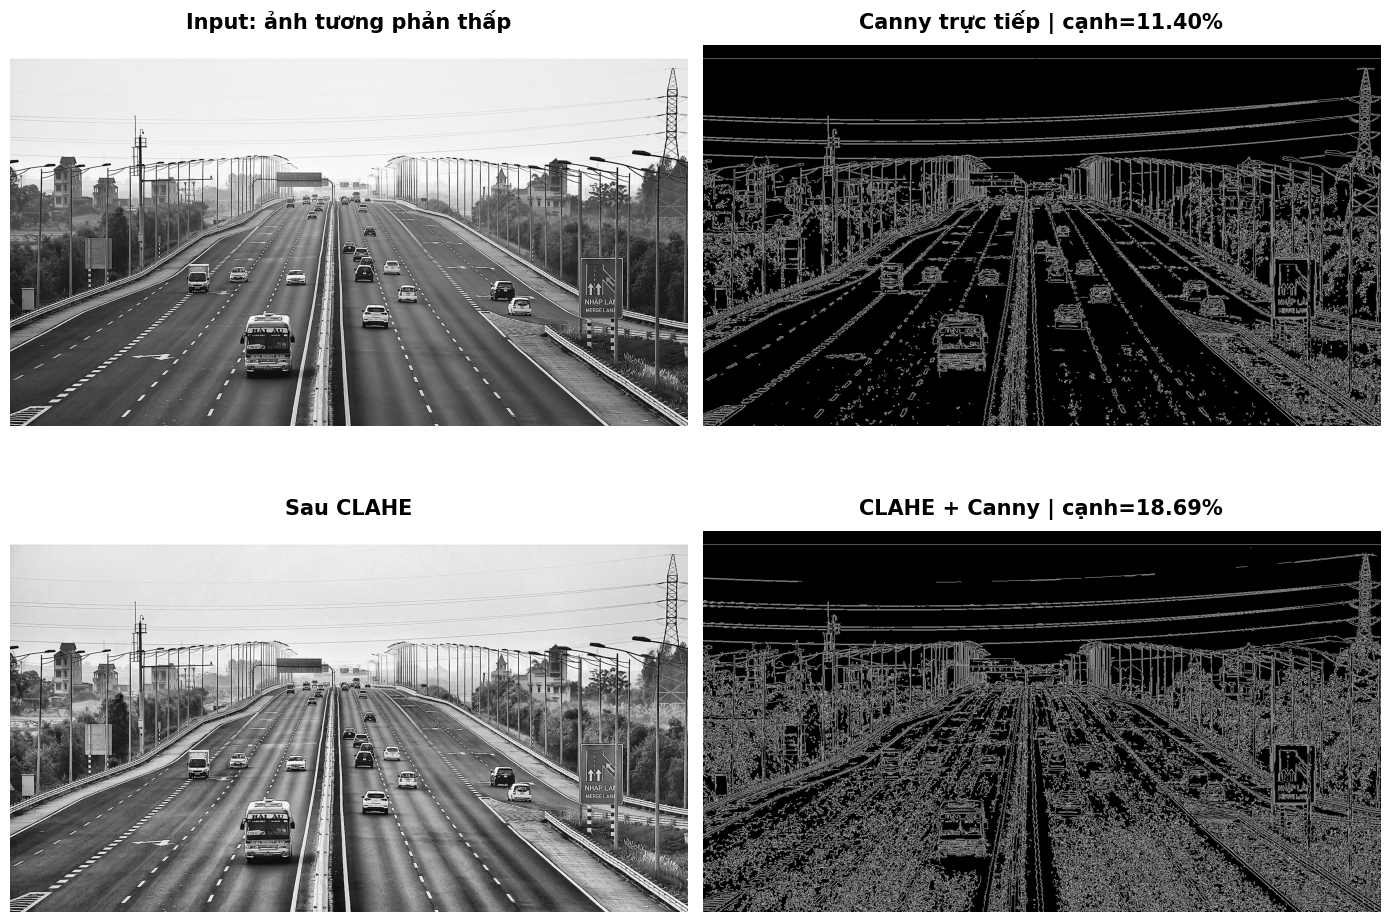

In [29]:
LOW_CONTRAST_INPUT = 'image/input_II_3_tuong_phan_thap.jpg'
low_contrast = cv2.imread(LOW_CONTRAST_INPUT, cv2.IMREAD_GRAYSCALE)
if low_contrast is None:
    raise FileNotFoundError(LOW_CONTRAST_INPUT)

low_direct = cv2.Canny(low_contrast, 60, 120)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(low_contrast)
low_edges = cv2.Canny(enhanced, 60, 120)

show_and_save(
    [
        ('Input: ảnh tương phản thấp', low_contrast),
        (f'Canny trực tiếp | cạnh={edge_ratio(low_direct):.2f}%', low_direct),
        ('Sau CLAHE', enhanced),
        (f'CLAHE + Canny | cạnh={edge_ratio(low_edges):.2f}%', low_edges),
    ],
    'II_3_anh_tuong_phan_thap.png',
    cols=2,
)

## Phần 2: Đánh giá kết quả và rút ra kết luận

- Với ảnh nhiều nhiễu, Canny trực tiếp nhận cả nhiễu thành cạnh. Median làm
  giảm rõ rệt các cạnh giả và giữ lại đường biên chính của vật thể.
- Với ảnh tương phản thấp, Canny trực tiếp bỏ sót nhiều cạnh yếu. CLAHE làm rõ
  chênh lệch sáng tối nên đường biên đồng xu liên tục và dễ quan sát hơn.
- Canny phụ thuộc mạnh vào chất lượng ảnh đầu vào. Cần chọn tiền xử lý theo
  nguyên nhân gây khó khăn: lọc nhiễu cho ảnh nhiễu, tăng tương phản cho ảnh
  có độ tương phản thấp.


# Câu II.4. Kết hợp Canny với các kỹ thuật khác

## Phần 1: Kết hợp với thuật toán phân đoạn để tìm các vùng trong ảnh

Đọc ảnh input riêng `image/input_II_4_phan_doan.png`. Canny tìm đường biên,
phép đóng hình thái nối các đoạn biên gần nhau, sau đó contour được dùng để
vẽ và tô các vùng tìm thấy.

In [33]:
SEGMENTATION_INPUT = 'image/input_II_4_phan_doan.jpg'
region_image = cv2.imread(SEGMENTATION_INPUT, cv2.IMREAD_GRAYSCALE)
if region_image is None:
    raise FileNotFoundError(SEGMENTATION_INPUT)

region_edges = cv2.Canny(cv2.GaussianBlur(region_image, (5, 5), 1.0), 60, 120)
kernel = np.ones((5, 5), np.uint8)
region_closed = cv2.morphologyEx(region_edges, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(region_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
coin_contours = [c for c in contours if 700 <= cv2.contourArea(c) <= 5000]

region_result = cv2.cvtColor(region_image, cv2.COLOR_GRAY2RGB)
overlay = region_result.copy()
cv2.drawContours(overlay, coin_contours, -1, (255, 180, 0), cv2.FILLED)
region_result = cv2.addWeighted(region_result, 0.62, overlay, 0.38, 0)
cv2.drawContours(region_result, coin_contours, -1, (0, 255, 0), 2)

print(f'Số vùng tìm được: {len(coin_contours)}')
show_and_save(
    [
        ('Input phân đoạn', region_image),
        ('Biên Canny', region_edges),
        ('Các vùng được vẽ từ chi tiết ảnh', region_result),
    ],
    'II_4_phan_doan_vung.png',
    cols=3,
)

FileNotFoundError: image/input_II_4_phan_doan.jpg

## Phần 2: Kết hợp với thuật toán nhận dạng hình dạng để tìm đối tượng

Đọc ảnh input riêng `image/input_II_4_nhan_dang_hinh_dang.png`. Sau Canny,
contour và `approxPolyDP` được dùng để nhận dạng tam giác, hình chữ nhật và
hình tròn.

Kết quả nhận dạng: {'Object': 5, 'Triangle': 2, 'Rectangle': 1}


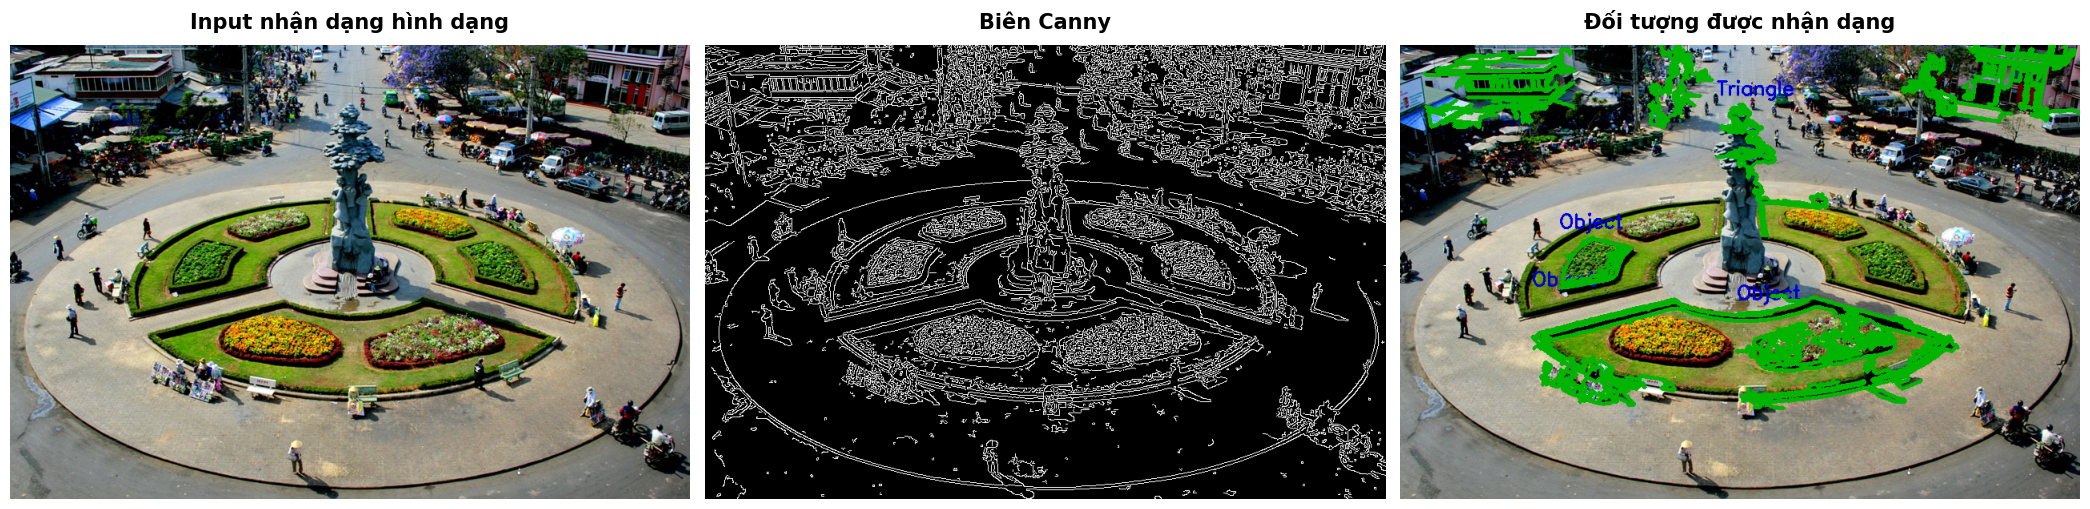

In [31]:
SHAPE_INPUT = 'image/input_II_4_nhan_dang_hinh_dang.jpg'
shape_image = cv2.imread(SHAPE_INPUT)
if shape_image is None:
    raise FileNotFoundError(SHAPE_INPUT)

shape_gray = cv2.cvtColor(shape_image, cv2.COLOR_BGR2GRAY)
shape_edges = cv2.Canny(shape_gray, 80, 160)
shape_contours, _ = cv2.findContours(shape_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

recognized = shape_image.copy()
shape_counts = {}
for contour in shape_contours:
    area = cv2.contourArea(contour)
    if area < 1000:
        continue
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.03 * perimeter, True)
    x, y, w, h = cv2.boundingRect(contour)
    circularity = 4 * np.pi * area / (perimeter ** 2)

    if len(approx) == 3:
        label = 'Triangle'
    elif len(approx) == 4:
        label = 'Rectangle'
    elif circularity > 0.75:
        label = 'Circle'
    else:
        label = 'Object'

    shape_counts[label] = shape_counts.get(label, 0) + 1
    cv2.drawContours(recognized, [contour], -1, (0, 180, 0), 3)
    cv2.putText(recognized, label, (x, y - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (220, 0, 0), 2)

print('Kết quả nhận dạng:', shape_counts)
show_and_save(
    [
        ('Input nhận dạng hình dạng', cv2.cvtColor(shape_image, cv2.COLOR_BGR2RGB)),
        ('Biên Canny', shape_edges),
        ('Đối tượng được nhận dạng', cv2.cvtColor(recognized, cv2.COLOR_BGR2RGB)),
    ],
    'II_4_nhan_dang_hinh_dang.png',
    cols=3,
)

# Kết luận Phần II

1. Hai hàm Canny có cách truyền dữ liệu và tham số khác nhau, nhưng đều dựa
   trên gradient và ngưỡng kép.
2. Tăng `sigma` làm giảm cạnh nhỏ; giảm ngưỡng giữ thêm cạnh yếu; tăng ngưỡng
   chỉ giữ các cạnh rõ.
3. Tiền xử lý đúng giúp Canny ổn định hơn trên ảnh nhiễu và ảnh tương phản thấp.
4. Canny tạo đường biên; muốn tìm vùng hoặc nhận dạng đối tượng cần kết hợp
   morphology, contour và đặc trưng hình dạng.
